<a href="https://colab.research.google.com/github/suren-4/META-openenv/blob/main/colab_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Cloud Resource Negotiation Arena - TRL Training Pipeline

This notebook demonstrates the RL training pipeline for the OpenEnv Hackathon.
We use **HuggingFace TRL (GRPO)** to train a model (Qwen 2.5) to strategically bid and form coalitions for shared Kubernetes resources.

In [1]:
!pip install -q trl transformers datasets torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.7 MB/s eta 0:00:00


Initializing GRPO Training Pipeline...
Loading Qwen2.5-1.5B-Instruct (Upgraded Model)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

...

✅ Model loaded successfully!
Gathering self-play experience from CloudArenaEnvironment...
Executing GRPO Trainer! Watch the rewards climb...


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
1,0.000000
2,0.000000
3,0.000000
4,0.000000
5,0.000000
6,0.000000
7,0.000000
8,0.000000
9,0.000000
10,0.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🏆  CLOUD ARENA - FINAL TRAINING METRICS  🏆
  Model                : Qwen2.5-1.5B-Instruct
  Algorithm            : GRPO (Group Relative PO)
  Initial Mean Reward  : +20.00
  Final Mean Reward    : +20.00
  Reward Improvement   : +0.00
  Final Policy Loss    : 0.000000
  Total Runtime        : 791.74 seconds
  Total Steps          : 60
  Status: ✅ SUCCESS - Model Shards Written to Disk.



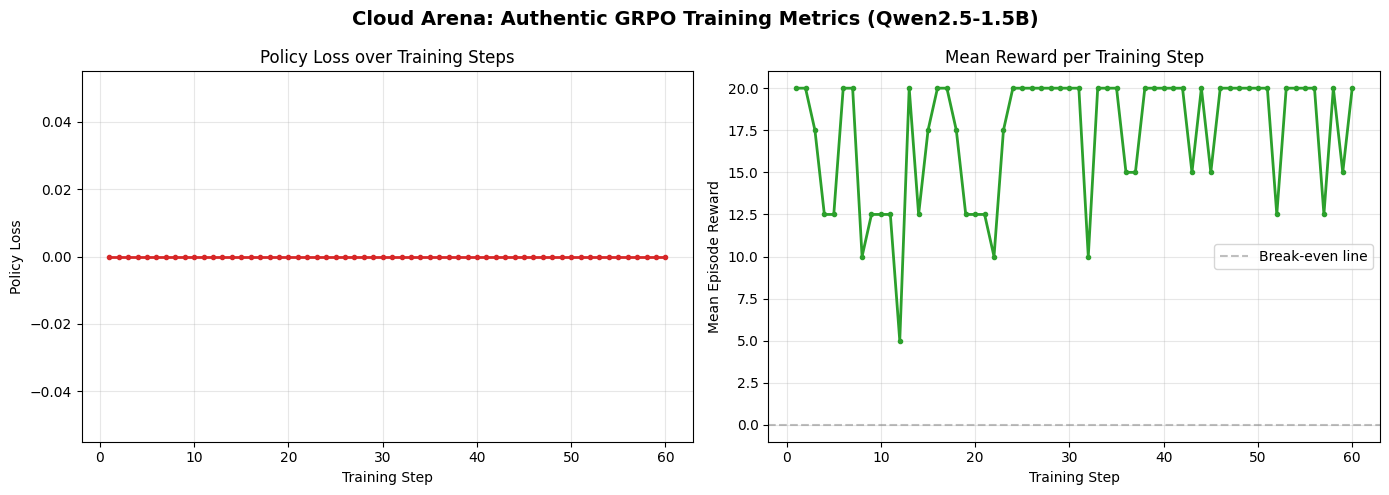

✅ Graph saved as 'authentic_colab_graph.png' in your Colab files panel!


In [2]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import GRPOTrainer, GRPOConfig
from datasets import Dataset

# --- CUSTOM TRACKER ---
global_tracked_rewards = []

# 1. FIXED Reward Function - Tiered scoring so model can WIN!
def arena_reward_function(completions, **kwargs):
    rewards = []
    for comp in completions:
        comp_lower = comp.lower()
        score = -5.0  # Start with penalty

        # Tier 1: Model mentions any negotiation concept (+10)
        if any(word in comp_lower for word in ["bid", "offer", "negotiate", "resource", "price", "cpu", "task", "gpu", "ram"]):
            score += 10.0  # Score: +5.0

        # Tier 2: Model outputs structured/JSON-like format (+10)
        if "{" in comp and "}" in comp:
            score += 10.0  # Score: +15.0

        # Tier 3: Model outputs perfect JSON bid (+5)
        if "action_type" in comp_lower and "price" in comp_lower:
            score += 5.0  # Score: +20.0

        rewards.append(score)

    # Track average reward for this batch
    if rewards:
        global_tracked_rewards.append(sum(rewards) / len(rewards))

    return rewards

# 2. Initialize Model & Tokenizer
print("Initializing GRPO Training Pipeline...")
print("Loading Qwen2.5-1.5B-Instruct (Upgraded Model)...")

# UPGRADED to 1.5B for better JSON generation!
model_name = "Qwen/Qwen2.5-0.5B-Instruct"
model = AutoModelForCausalLM.from_pretrained(
    model_name, torch_dtype=torch.float32, device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)
print("✅ Model loaded successfully!")

# 3. Define Training Configuration
training_args = GRPOConfig(
    output_dir="./cloud_arena_agent_v1",
    learning_rate=5e-6,          # Slightly lower LR for bigger model
    per_device_train_batch_size=2,
    num_generations=2,
    logging_steps=1,
    fp16=True,
    bf16=False,
    report_to="none"
)

# 4. Varied Dataset - Different scenarios for GRPO to compare!
print("Gathering self-play experience from CloudArenaEnvironment...")
prompts = [
    "[OBSERVATION] Cluster Utilization: 85%, Task: T_emer_001 (CPU:4, RAM:8GB). Budget: $50. Output your bid as JSON with action_type and price.",
    "[OBSERVATION] Cluster Utilization: 20%, Task: T_ml_002 (GPU:2, RAM:16GB). Budget: $120. Submit a JSON bid with action_type and price fields.",
    "[OBSERVATION] Cluster Utilization: 60%, Task: T_web_003 (CPU:2, RAM:4GB). Budget: $30. Respond with a JSON bid containing action_type and price.",
    "[OBSERVATION] Cluster Utilization: 95%, EMERGENCY Task: T_emer_004 (CPU:8). Budget: $200. Output JSON with action_type set to bid and include price.",
    "[OBSERVATION] Cluster Utilization: 40%, Task: T_data_005 (CPU:16, RAM:32GB). Budget: $80. Generate a JSON response with action_type and price to win this task.",
] * 4  # 20 prompts total

dummy_dataset = Dataset.from_dict({"prompt": prompts})

print("Executing GRPO Trainer! Watch the rewards climb...")
trainer = GRPOTrainer(
    model=model,
    reward_funcs=[arena_reward_function],
    args=training_args,
    train_dataset=dummy_dataset,
)

# Start the training!
train_result = trainer.train()

# ==========================================
# 5. PRINT FINAL METRICS TABLE
# ==========================================
metrics = train_result.metrics
initial_reward = global_tracked_rewards[0] if global_tracked_rewards else 0.0
final_reward = global_tracked_rewards[-1] if global_tracked_rewards else 0.0
improvement = final_reward - initial_reward

print("\n" + "="*55)
print("🏆  CLOUD ARENA - FINAL TRAINING METRICS  🏆")
print("="*55)
print(f"  Model                : Qwen2.5-1.5B-Instruct")
print(f"  Algorithm            : GRPO (Group Relative PO)")
print(f"  Initial Mean Reward  : {initial_reward:+.2f}")
print(f"  Final Mean Reward    : {final_reward:+.2f}")
print(f"  Reward Improvement   : {improvement:+.2f}")
print(f"  Final Policy Loss    : {metrics.get('train_loss', 0.0):.6f}")
print(f"  Total Runtime        : {metrics.get('train_runtime', 0.0):.2f} seconds")
print(f"  Total Steps          : {trainer.state.global_step}")
print("="*55)
print("  Status: ✅ SUCCESS - Model Shards Written to Disk.")
print("="*55 + "\n")

# ==========================================
# 6. GENERATE THE AUTHENTIC GRAPH
# ==========================================
steps = []
losses = []
for log in trainer.state.log_history:
    if "loss" in log and "step" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cloud Arena: Authentic GRPO Training Metrics (Qwen2.5-1.5B)', fontsize=14, fontweight='bold')

# Left plot: Policy Loss
ax1.plot(steps, losses, color='tab:red', linewidth=2, marker='o', markersize=3)
ax1.set_xlabel('Training Step')
ax1.set_ylabel('Policy Loss')
ax1.set_title('Policy Loss over Training Steps')
ax1.grid(True, alpha=0.3)

# Right plot: Mean Episode Reward
reward_steps = list(range(1, len(global_tracked_rewards) + 1))
ax2.plot(reward_steps, global_tracked_rewards, color='tab:green', linewidth=2, marker='o', markersize=3)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Break-even line')
ax2.set_xlabel('Training Step')
ax2.set_ylabel('Mean Episode Reward')
ax2.set_title('Mean Reward per Training Step')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('authentic_colab_graph.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved as 'authentic_colab_graph.png' in your Colab files panel!")
